In [10]:
# Cell 1: Initial Setup and Core Imports

import sys
import os

# --- IMPORTANT: Add the project root directory to the Python path ---
# This ensures that Python can find modules like 'utils' when running from the notebook.
# It assumes the notebook is located at: your_project_root/notebooks/
# And the 'utils' folder is located at: your_project_root/utils/
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
print(f"Added '{project_root}' to sys.path for module discovery.")

# Print current working directory for debugging relative paths
print("Current Working Directory (Notebook):", os.getcwd())

# Core machine learning and data handling imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping # Import callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import json # For saving class names
import matplotlib.pyplot as plt
import seaborn as sns

# Import your data_loader module from utils
from utils.data_loader import load_devanagari_dataset

print("TensorFlow version:", tf.__version__)
print("All necessary modules imported.")

Added 'c:\Users\anamo\OneDrive\Desktop\aiProject' to sys.path for module discovery.
Current Working Directory (Notebook): c:\Users\anamo\OneDrive\Desktop\aiProject\notebooks
TensorFlow version: 2.19.0
All necessary modules imported.


In [11]:
# Cell 2: Configuration and Path Verification

# --- IMPORTANT: Configure your DATA_ROOT_DIR ---
# This path is RELATIVE to your project root (the 'aiProject' folder).
# Example: If your data is at C:\Users\YourUser\aiProject\data\archive\nhcd\nhcd
# and your notebook is in aiProject/notebooks, this relative path is correct.
DATA_ROOT_DIR_RELATIVE = "data/archive/nhcd/nhcd"

# These preprocessing settings MUST be consistent with what your model expects
# and what the API will use during prediction.
MODEL_TARGET_SIZE = (64, 64) # Target size for image preprocessing (e.g., 64x64 pixels)
MODEL_GRAYSCALE = True       # Whether the model expects grayscale images (True means 1 channel, False means 3 channels)
MODEL_NORMALIZE = True       # Whether pixel values should be normalized to [0, 1]

# Define paths for saving model and class names.
# These paths are relative to the project root (aiProject base folder).
MODEL_SAVE_PATH = 'models/devanagari_model.h5'
CLASS_NAMES_JSON_PATH = 'models/class_names.json'

print(f"\n--- Data and Model Configuration ---")
print(f"Configured DATA_ROOT_DIR (relative to project root): '{DATA_ROOT_DIR_RELATIVE}'")

# Calculate the full absolute path to the data for verification
# This assumes the notebook is in 'notebooks' folder, and the project root is one level up.
current_working_dir = os.getcwd()
project_root_calculated = os.path.abspath(os.path.join(current_working_dir, '..'))

# Construct the full absolute path to the data using os.path.join for platform independence
DATA_ROOT_DIR_ABSOLUTE = os.path.join(project_root_calculated, DATA_ROOT_DIR_RELATIVE)

print(f"Calculated Project Root: '{project_root_calculated}'")
print(f"Full ABSOLUTE path to dataset: '{DATA_ROOT_DIR_ABSOLUTE}'")
print(f"Does full dataset path exist? {os.path.exists(DATA_ROOT_DIR_ABSOLUTE)}")
print(f"Is full dataset path a directory? {os.path.isdir(DATA_ROOT_DIR_ABSOLUTE)}")

# --- Important: If the above 'exist' and 'is directory' checks return False,
# you MUST correct DATA_ROOT_DIR_RELATIVE or your project structure.
# The data loading will fail otherwise. ---

print(f"\nModel preprocessing settings:")
print(f"  Target Size: {MODEL_TARGET_SIZE}")
print(f"  Grayscale: {MODEL_GRAYSCALE}")
print(f"  Normalize: {MODEL_NORMALIZE}")

print(f"\nModel and Class Names Save Paths:")
print(f"  Model will be saved to: '{MODEL_SAVE_PATH}' (absolute: '{os.path.abspath(os.path.join(project_root_calculated, MODEL_SAVE_PATH))}')")
print(f"  Class names will be saved to: '{CLASS_NAMES_JSON_PATH}' (absolute: '{os.path.abspath(os.path.join(project_root_calculated, CLASS_NAMES_JSON_PATH))}')")


--- Data and Model Configuration ---
Configured DATA_ROOT_DIR (relative to project root): 'data/archive/nhcd/nhcd'
Calculated Project Root: 'c:\Users\anamo\OneDrive\Desktop\aiProject'
Full ABSOLUTE path to dataset: 'c:\Users\anamo\OneDrive\Desktop\aiProject\data/archive/nhcd/nhcd'
Does full dataset path exist? True
Is full dataset path a directory? True

Model preprocessing settings:
  Target Size: (64, 64)
  Grayscale: True
  Normalize: True

Model and Class Names Save Paths:
  Model will be saved to: 'models/devanagari_model.h5' (absolute: 'c:\Users\anamo\OneDrive\Desktop\aiProject\models\devanagari_model.h5')
  Class names will be saved to: 'models/class_names.json' (absolute: 'c:\Users\anamo\OneDrive\Desktop\aiProject\models\class_names.json')


In [12]:
# Cell 3: Load the Dataset

print("Loading Devanagari dataset...")
try:
    X, y, class_names = load_devanagari_dataset(
        data_root_dir_absolute=DATA_ROOT_DIR_ABSOLUTE,
        target_size=MODEL_TARGET_SIZE,
        grayscale=MODEL_GRAYSCALE,
        normalize=MODEL_NORMALIZE
    )
    print(f"Dataset loaded: {len(X)} images, {len(class_names)} classes.")
    # Ensure y is one-hot encoded for categorical crossentropy if needed,
    # but for sparse_categorical_crossentropy, integer labels are fine.
    # If your model's last layer activation is 'softmax' and loss is 'categorical_crossentropy',
    # you'll need to uncomment: y = tf.keras.utils.to_categorical(y, num_classes=len(class_names))
    # For now, let's assume sparse_categorical_crossentropy.
    print(f"First 5 labels: {y[:5]}")
    print(f"First 5 class names: {class_names[:5]}")
except Exception as e:
    print(f"ERROR: Failed to load dataset: {e}")
    X = np.array([])
    y = np.array([])
    class_names = []

Loading Devanagari dataset...
Processing category: c:\Users\anamo\OneDrive\Desktop\aiProject\data/archive/nhcd/nhcd\consonants
    Loaded 205 images from folder '1' (Devanagari: 'अ').
    Loaded 205 images from folder '10' (Devanagari: 'ओ').
    Loaded 205 images from folder '11' (Devanagari: 'औ').
    Loaded 205 images from folder '12' (Devanagari: 'अं').
    Loaded 205 images from folder '13' (Devanagari: 'अः').
    Loaded 205 images from folder '14' (Devanagari: 'ढ').
    Loaded 205 images from folder '15' (Devanagari: 'ण').
    Loaded 205 images from folder '16' (Devanagari: 'त').
    Loaded 205 images from folder '17' (Devanagari: 'थ').
    Loaded 205 images from folder '18' (Devanagari: 'द').
    Loaded 205 images from folder '19' (Devanagari: 'ध').
    Loaded 205 images from folder '2' (Devanagari: 'आ').
    Loaded 205 images from folder '20' (Devanagari: 'न').
    Loaded 205 images from folder '21' (Devanagari: 'प').
    Loaded 205 images from folder '22' (Devanagari: 'फ').
   

In [13]:
# Cell 4: Split Data into Training, Validation, and Test Sets

if len(X) == 0:
    print("Cannot split data: No images loaded.")
else:
    # Split into training (80%) and temporary (20%)
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Split temporary into validation (10% of total) and test (10% of total)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

    print(f"Training set size: {len(X_train)} images")
    print(f"Validation set size: {len(X_val)} images")
    print(f"Test set size: {len(X_test)} images")

Training set size: 10329 images
Validation set size: 1291 images
Test set size: 1292 images


In [14]:
# Cell 5: Define the CNN Model Architecture

def build_cnn_model(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5), # Add dropout for regularization
        Dense(num_classes, activation='softmax') # Output layer, num_classes neurons
    ])
    return model

if len(X) > 0:
    # Determine input shape based on preprocessing (height, width, channels)
    input_shape = X_train.shape[1:]
    num_classes = len(class_names)

    model = build_cnn_model(input_shape, num_classes)
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy', # Use sparse if labels are integers
                  metrics=['accuracy'])

    model.summary()
else:
    print("Skipping model definition: No data available.")

c:\Users\anamo\OneDrive\Desktop\aiProject\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,146,149 (4.37 MB)

 Trainable params: 1,146,149 (4.37 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Cell 6: Train the Model

if 'model' in locals() and model is not None and len(X_train) > 0:
    epochs = 20 # You can adjust the number of epochs
    batch_size = 32

    # Define callbacks
    # Saves the best model based on validation accuracy
    checkpoint_filepath = os.path.join(project_root, MODEL_SAVE_PATH)
    model_checkpoint_callback = ModelCheckpoint(
        filepath=checkpoint_filepath,
        save_weights_only=False, # Save the entire model
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    )

    # Stops training if validation accuracy doesn't improve for 'patience' epochs
    early_stopping_callback = EarlyStopping(
        monitor='val_accuracy',
        patience=5, # Number of epochs with no improvement after which training will be stopped.
        mode='max',
        verbose=1
        )

    print("Starting model training...")
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        callbacks=[model_checkpoint_callback, early_stopping_callback]
    )
    print("Model training complete.")
else:
    print("Skipping model training: Model not defined or no training data.")
    history = None

Starting model training...
Epoch 1/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.1056 - loss: 3.2707
Epoch 1: val_accuracy improved from -inf to 0.51123, saving model to c:\Users\anamo\OneDrive\Desktop\aiProject\models/devanagari_model.h5


323/323 ━━━━━━━━━━━━━━━━━━━━ 44s 122ms/step - accuracy: 0.1058 - loss: 3.2696 - val_accuracy: 0.5112 - val_loss: 1.7924
Epoch 2/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.3803 - loss: 2.1129
Epoch 2: val_accuracy improved from 0.51123 to 0.72657, saving model to c:\Users\anamo\OneDrive\Desktop\aiProject\models/devanagari_model.h5


323/323 ━━━━━━━━━━━━━━━━━━━━ 39s 121ms/step - accuracy: 0.3804 - loss: 2.1124 - val_accuracy: 0.7266 - val_loss: 1.0808
Epoch 3/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.5335 - loss: 1.5005
Epoch 3: val_accuracy improved from 0.72657 to 0.78311, saving model to c:\Users\anamo\OneDrive\Desktop\aiProject\models/devanagari_model.h5


323/323 ━━━━━━━━━━━━━━━━━━━━ 36s 111ms/step - accuracy: 0.5335 - loss: 1.5004 - val_accuracy: 0.7831 - val_loss: 0.7917
Epoch 4/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.6277 - loss: 1.1788
Epoch 4: val_accuracy improved from 0.78311 to 0.83888, saving model to c:\Users\anamo\OneDrive\Desktop\aiProject\models/devanagari_model.h5


323/323 ━━━━━━━━━━━━━━━━━━━━ 35s 108ms/step - accuracy: 0.6277 - loss: 1.1787 - val_accuracy: 0.8389 - val_loss: 0.6189
Epoch 5/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.6859 - loss: 0.9788
Epoch 5: val_accuracy did not improve from 0.83888
323/323 ━━━━━━━━━━━━━━━━━━━━ 35s 108ms/step - accuracy: 0.6859 - loss: 0.9788 - val_accuracy: 0.8335 - val_loss: 0.5652
Epoch 6/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7304 - loss: 0.8227
Epoch 6: val_accuracy improved from 0.83888 to 0.87916, saving model to c:\Users\anamo\OneDrive\Desktop\aiProject\models/devanagari_model.h5


...

323/323 ━━━━━━━━━━━━━━━━━━━━ 42s 129ms/step - accuracy: 0.8124 - loss: 0.5395 - val_accuracy: 0.8923 - val_loss: 0.3874
Epoch 10/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.8425 - loss: 0.4695
Epoch 10: val_accuracy did not improve from 0.89233
323/323 ━━━━━━━━━━━━━━━━━━━━ 40s 124ms/step - accuracy: 0.8425 - loss: 0.4695 - val_accuracy: 0.8885 - val_loss: 0.3791
Epoch 11/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.8503 - loss: 0.4335
Epoch 11: val_accuracy improved from 0.89233 to 0.90163, saving model to c:\Users\anamo\OneDrive\Desktop\aiProject\models/devanagari_model.h5


323/323 ━━━━━━━━━━━━━━━━━━━━ 40s 123ms/step - accuracy: 0.8503 - loss: 0.4335 - val_accuracy: 0.9016 - val_loss: 0.3666
Epoch 12/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.8571 - loss: 0.3983
Epoch 12: val_accuracy did not improve from 0.90163
323/323 ━━━━━━━━━━━━━━━━━━━━ 40s 118ms/step - accuracy: 0.8571 - loss: 0.3983 - val_accuracy: 0.9001 - val_loss: 0.3641
Epoch 13/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.8713 - loss: 0.3658
Epoch 13: val_accuracy did not improve from 0.90163
323/323 ━━━━━━━━━━━━━━━━━━━━ 37s 114ms/step - accuracy: 0.8713 - loss: 0.3658 - val_accuracy: 0.8931 - val_loss: 0.3837
Epoch 14/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.8787 - loss: 0.3404
Epoch 14: val_accuracy did not improve from 0.90163
323/323 ━━━━━━━━━━━━━━━━━━━━ 38s 117ms/step - accuracy: 0.8787 - loss: 0.3405 - val_accuracy: 0.9009 - val_loss: 0.3502
Epoch 15/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.8902 - loss: 0.3137
Epoch 15

323/323 ━━━━━━━━━━━━━━━━━━━━ 38s 118ms/step - accuracy: 0.8902 - loss: 0.3138 - val_accuracy: 0.9024 - val_loss: 0.3547
Epoch 16/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.8886 - loss: 0.3179
Epoch 16: val_accuracy improved from 0.90240 to 0.90782, saving model to c:\Users\anamo\OneDrive\Desktop\aiProject\models/devanagari_model.h5


323/323 ━━━━━━━━━━━━━━━━━━━━ 38s 117ms/step - accuracy: 0.8886 - loss: 0.3179 - val_accuracy: 0.9078 - val_loss: 0.3516
Epoch 17/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.9029 - loss: 0.2843
Epoch 17: val_accuracy improved from 0.90782 to 0.91170, saving model to c:\Users\anamo\OneDrive\Desktop\aiProject\models/devanagari_model.h5


323/323 ━━━━━━━━━━━━━━━━━━━━ 39s 119ms/step - accuracy: 0.9029 - loss: 0.2843 - val_accuracy: 0.9117 - val_loss: 0.3534
Epoch 18/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.9080 - loss: 0.2592
Epoch 18: val_accuracy did not improve from 0.91170
323/323 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - accuracy: 0.9079 - loss: 0.2593 - val_accuracy: 0.8985 - val_loss: 0.3693
Epoch 19/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9016 - loss: 0.2806
Epoch 19: val_accuracy did not improve from 0.91170
323/323 ━━━━━━━━━━━━━━━━━━━━ 38s 116ms/step - accuracy: 0.9016 - loss: 0.2806 - val_accuracy: 0.9101 - val_loss: 0.3550
Epoch 20/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9067 - loss: 0.2612
Epoch 20: val_accuracy did not improve from 0.91170
323/323 ━━━━━━━━━━━━━━━━━━━━ 37s 115ms/step - accuracy: 0.9067 - loss: 0.2612 - val_accuracy: 0.9086 - val_loss: 0.3560
Model training complete.


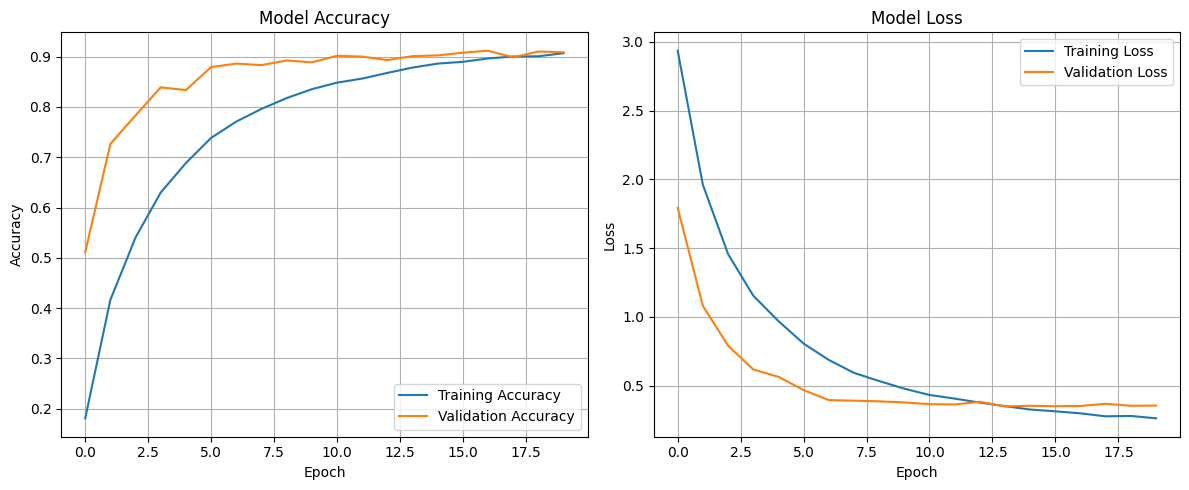

In [16]:
# Cell 7: Plot Training History

if history:
    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("No training history to plot.")


Evaluating model on the test set...
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9117 - loss: 0.2948
Test Loss: 0.3719
Test Accuracy: 0.9025
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step

Classification Report:
              precision    recall  f1-score   support

           अ       0.86      0.99      0.92        72
           ओ       0.85      0.81      0.83        43
           औ       0.92      0.84      0.88        43
          अं       1.00      0.95      0.98        43
          अः       0.89      0.80      0.84        20
           ढ       0.83      1.00      0.91        20
           ण       1.00      0.90      0.95        20
           त       0.87      1.00      0.93        20
           थ       0.82      0.90      0.86        20
           द       0.91      1.00      0.95        20
           ध       0.90      0.86      0.88        21
           आ       0.93      0.89      0.91        72
           न       0.87      0.95      0.91        21
           प       0.86     

c:\Users\anamo\OneDrive\Desktop\aiProject\venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2309 (\N{DEVANAGARI LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\anamo\OneDrive\Desktop\aiProject\venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.draw()
c:\Users\anamo\OneDrive\Desktop\aiProject\venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2323 (\N{DEVANAGARI LETTER O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\anamo\OneDrive\Desktop\aiProject\venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2324 (\N{DEVANAGARI LETTER AU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\anamo\OneDrive\Desktop\aiProject\venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2306 (\N{DEVANAGARI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\anamo\OneDrive\Desktop\aiProject\venv\Lib\site-

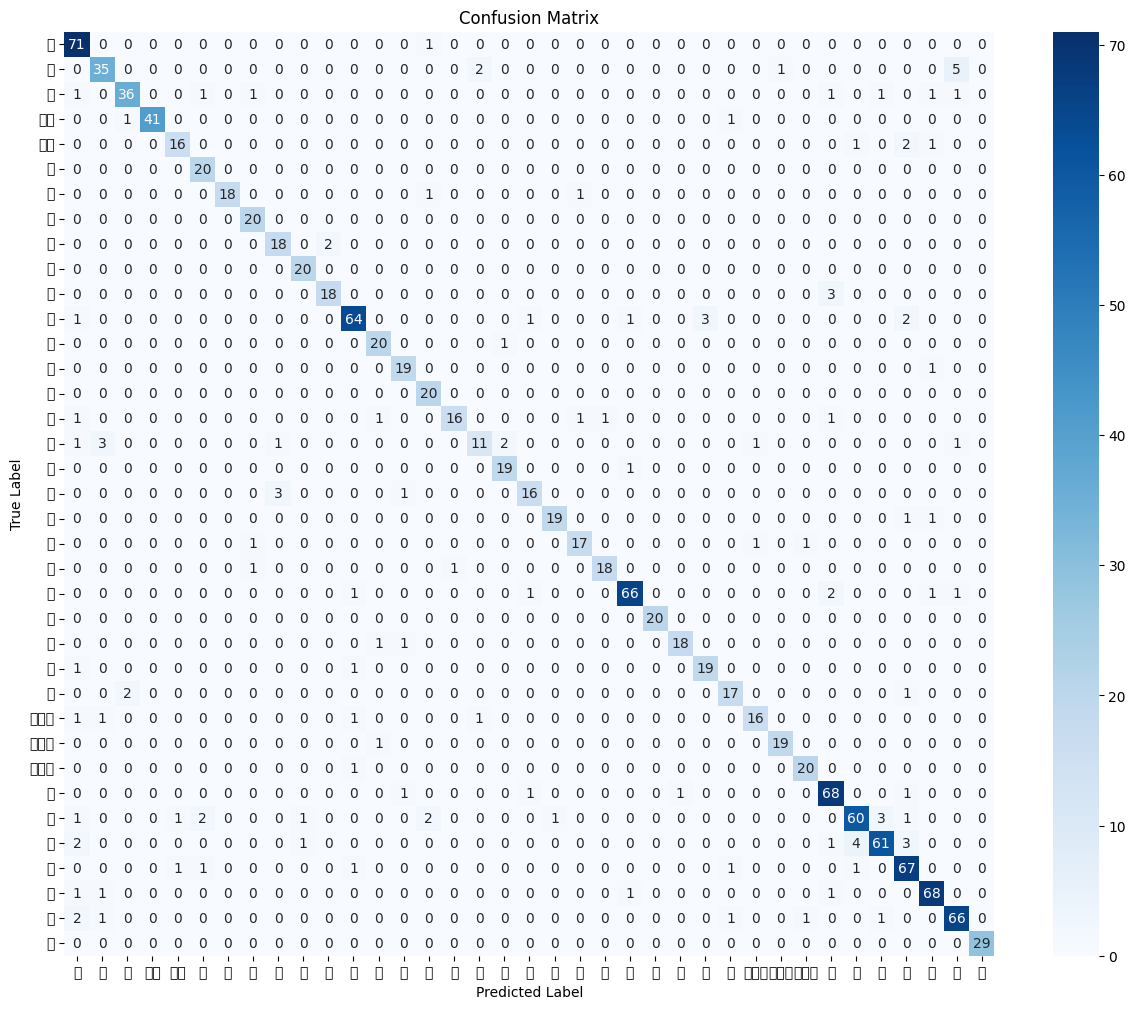

In [17]:
# Cell 8: Evaluate the Model on the Test Set

if 'model' in locals() and model is not None and len(X_test) > 0:
    print("\nEvaluating model on the test set...")
    loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
    print(f"Test Loss: {loss:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")

    # Generate predictions for classification report and confusion matrix
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(15, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

else:
    print("Skipping model evaluation: Model not defined or no test data.")

In [18]:
# Cell 9: Save the Final Trained Model and Class Names

if 'model' in locals() and model is not None and len(class_names) > 0:
    # Save the final model (even if not the best, ensures a model is saved)
    # ModelCheckpoint saved the best one, this saves the last one.
    # Using the absolute path as derived in Cell 2
    final_model_save_absolute_path = os.path.abspath(os.path.join(project_root, MODEL_SAVE_PATH))
    print(f"Attempting to save final model to: {final_model_save_absolute_path}")
    model.save(final_model_save_absolute_path)
    print("Model saved successfully.")

    # Save class names to a JSON file
    final_class_names_json_absolute_path = os.path.abspath(os.path.join(project_root, CLASS_NAMES_JSON_PATH))
    print(f"Attempting to save class names to: {final_class_names_json_absolute_path}")
    with open(final_class_names_json_absolute_path, 'w', encoding='utf-8') as f:
        json.dump(class_names, f, ensure_ascii=False, indent=4)
    print("Class names saved successfully.")
else:
    print("Skipping model and class names saving: Model not defined or no class names.")

Attempting to save final model to: c:\Users\anamo\OneDrive\Desktop\aiProject\models\devanagari_model.h5
Model saved successfully.
Attempting to save class names to: c:\Users\anamo\OneDrive\Desktop\aiProject\models\class_names.json
Class names saved successfully.
